# 03 — Explicabilité des Modèles
## Projet ObRail Europe — Prévision de fréquentation & Détection des pays en déclin

**Objectif :** Produire les visualisations d'explicabilité des modèles sélectionnés :
- Importance des variables — XGBoost optimisé (classification)
- Analyse SHAP globale — XGBoost optimisé (classification)
- Explication SHAP individuelle — XGBoost optimisé (classification)
- Importance des variables via les coefficients — Ridge baseline (régression)
- Analyse SHAP globale — Ridge baseline (régression)
- Figures finales exportées pour la documentation

**Variables attendues comme importantes :** 
- passengers_lag1 → dynamique récente (signal le plus fort)
- passengers_lag2 → tendance historique sur deux années
- co2_per_passenger → indicateur d'efficacité environnementale
- year → évolution temporelle globale

**Livrables :** 
- notebooks/03_explicabilite.ipynb
- docs/fig_feature_importance_clf.png
- docs/fig_feature_importance_reg.png
- docs/fig_shap_clf.png
- docs/fig_shap_reg.png

In [8]:
# Imports principaux pour les chemins, données, graphiques et explicabilité.
from pathlib import Path
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap


# Recherche automatique de la racine du projet.
ROOT = Path.cwd()
for parent in [ROOT] + list(ROOT.parents):
    if (parent / 'ia').exists() and (parent / 'docs').exists():
        ROOT = parent
        break
sys.path.insert(0, str(ROOT))


# Dossier où les figures finales seront exportées.
def find_docs_dir():
    for p in [Path.cwd()] + list(Path.cwd().parents):
        candidate = p / 'docs'
        if candidate.exists():
            return candidate
    return Path.cwd() / 'docs'

DOCS_DIR = find_docs_dir()
DOCS_DIR.mkdir(parents=True, exist_ok=True)


# Fonctions projet pour charger les datasets, preprocessors et modèles.
from ia.src.ml.models.train_utils import (
    load_classification_data, prepare_classification_data,
    load_regression_data, prepare_regression_data,
    load_model_and_metrics
)


# Style visuel commun aux graphiques du notebook.
sns.set(style="whitegrid")


---
## Bloc 1. Classification (XGBoost optimisé)
Nous utilisons le modèle `xgboost_optimized` (axis='clf').

In [9]:
# Chargement et preprocessing du dataset de classification.
X_clf, y_clf = load_classification_data()
X_train_p, X_test_p, y_train_clf, y_test_clf, preprocessor_clf = prepare_classification_data(X_clf, y_clf)

# Récupération des noms de variables après transformation.
try:
    feature_names_clf = preprocessor_clf.get_feature_names_out()
except Exception:
    feature_names_clf = list(preprocessor_clf.transformers_[0][2]) + list(preprocessor_clf.transformers_[1][2])


# Chargement du modèle XGBoost optimisé, avec fallback si besoin.
try:
    xgb_model, _ = load_model_and_metrics('xgboost_optimized', axis='clf')
except Exception as e:
    print('Chargement via helper failed:', e)
    alt = Path('ia/models/xgboost_optimized_clf.joblib')
    if alt.exists():
        xgb_model = joblib.load(alt)
    else:
        raise FileNotFoundError('Modele XGBoost classification introuvable (ia/models/xgboost_optimized_clf.joblib)')


   [Classification] Dataset : 595 obs, 7 features
   Cible 'en_declin' : {0: 379, 1: 216}
   X_train: (476, 52) | X_test: (119, 52)


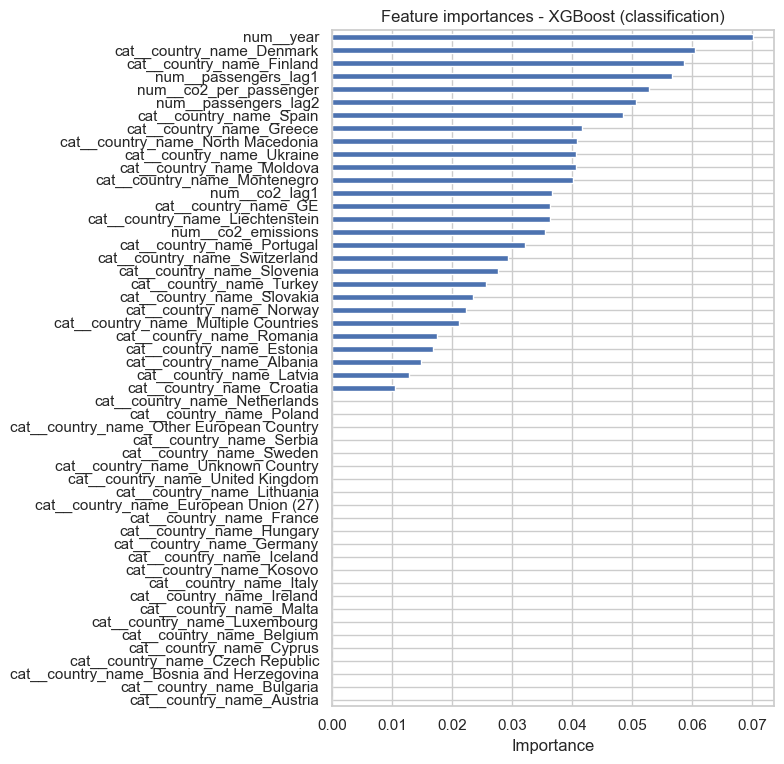

In [10]:
# Extraction de l'importance native des variables XGBoost.
importances = xgb_model.feature_importances_
if len(importances) == len(feature_names_clf):
    s = pd.Series(importances, index=feature_names_clf)
else:
    s = pd.Series(importances)

# Tri pour afficher les variables les plus importantes en haut du graphique.
s = s.sort_values(ascending=True)

# Création et sauvegarde du graphique d'importance.
plt.figure(figsize=(8, max(4, len(s) * 0.15)))
s.plot(kind='barh', color='C0')
plt.title('Feature importances - XGBoost (classification)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_feature_importance_clf.png', dpi=150)
plt.show()


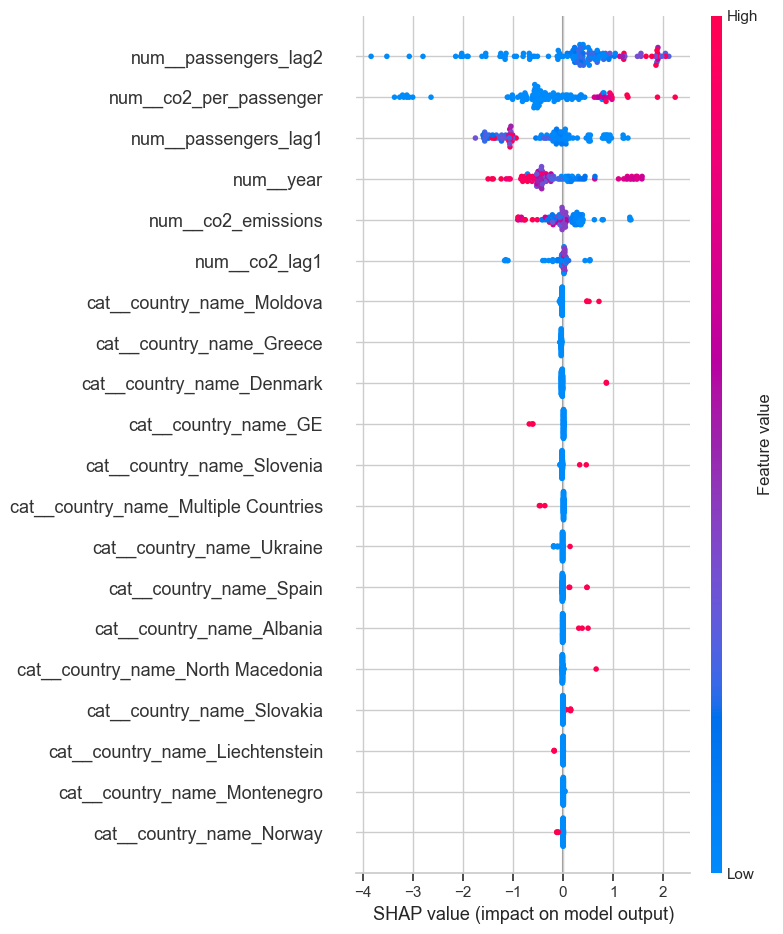

In [11]:
# Initialisation de SHAP pour expliquer les prédictions XGBoost.
explainer = shap.TreeExplainer(xgb_model)

# Limitation de l'échantillon si le test set est trop grand.
X_for_shap = X_test_p if X_test_p.shape[0] <= 2000 else X_test_p[np.random.choice(X_test_p.shape[0], 2000, replace=False)]

# Calcul des valeurs SHAP avec compatibilité entre versions.
try:
    shap_exp = explainer(X_for_shap)
    shap_values = shap_exp.values
except Exception:
    shap_values = explainer.shap_values(X_for_shap)


# Visualisation globale de l'effet des variables sur la prédiction.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_for_shap, feature_names=feature_names_clf, show=False)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_shap_clf.png', dpi=150)
plt.show()


---
## Bloc 2. Régression (Ridge baseline)
Nous utilisons le modèle `ridge` (axis='reg').

In [12]:
# Chargement et preprocessing du dataset de régression.
X_reg, y_reg = load_regression_data()
X_train_p_reg, X_test_p_reg, y_train_reg, y_test_reg, preprocessor_reg = prepare_regression_data(X_reg, y_reg)

# Récupération des noms de variables après transformation.
try:
    feature_names_reg = preprocessor_reg.get_feature_names_out()
except Exception:
    feature_names_reg = list(preprocessor_reg.transformers_[0][2]) + list(preprocessor_reg.transformers_[1][2])


# Chargement du modèle Ridge retenu, avec fallback si besoin.
try:
    ridge_model, _ = load_model_and_metrics('ridge', axis='reg')
except Exception as e:
    print('Chargement via helper failed:', e)
    alt = Path('ia/models/ridge_reg.joblib')
    if alt.exists():
        ridge_model = joblib.load(alt)
    else:
        raise FileNotFoundError('Modele Ridge regression introuvable (ia/models/ridge_reg.joblib)')


   [Régression] Dataset : 595 obs, 7 features
   Cible 'passengers' — min: 2 | max: 2094374 | médiane: 17938
   X_train: (476, 52) | X_test: (119, 52)


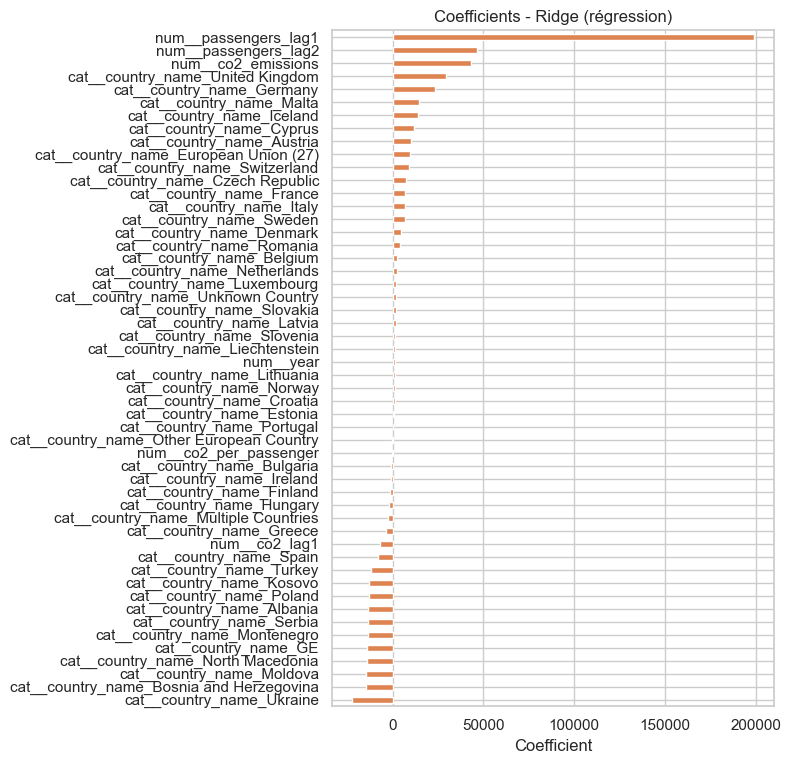

In [13]:
# Extraction des coefficients Ridge comme mesure d'influence des variables.
coefs = pd.Series(ridge_model.coef_, index=feature_names_reg) if len(ridge_model.coef_) == len(feature_names_reg) else pd.Series(ridge_model.coef_)

# Tri puis visualisation des coefficients positifs et négatifs.
coefs = coefs.sort_values(ascending=True)
plt.figure(figsize=(8, max(4, len(coefs) * 0.15)))
coefs.plot(kind='barh', color='C1')
plt.title('Coefficients - Ridge (régression)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_feature_importance_reg.png', dpi=150)
plt.show()


c:\Users\loadj\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
Background dataset has 476 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=476 when initializing the masker.


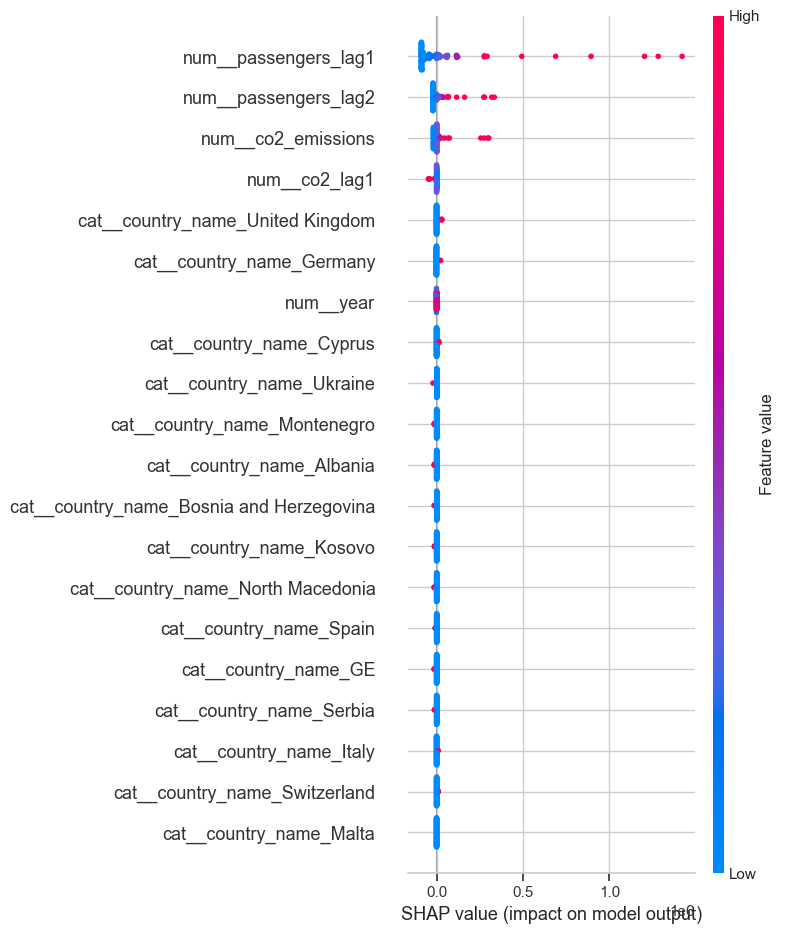

In [14]:
# Initialisation de SHAP pour le modèle lineaire Ridge.
explainer_reg = shap.LinearExplainer(ridge_model, X_train_p_reg, feature_perturbation="interventional")

# Calcul des valeurs SHAP avec compatibilité entre versions.
try:
    shap_exp_reg = explainer_reg(X_test_p_reg)
    shap_values_reg = shap_exp_reg.values
except Exception:
    shap_values_reg = explainer_reg.shap_values(X_test_p_reg)


# Visualisation globale de l'effet des variables sur la prédiction.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_reg, X_test_p_reg, feature_names=feature_names_reg, show=False)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig_shap_reg.png', dpi=150)
plt.show()
